In [10]:
from sklearn import datasets, tree, model_selection
import matplotlib.pyplot as plt
import numpy as np
import pydotplus
from IPython.display import Image

In [11]:
def plot_boundary(ax, data, tgt, model, dims, grid_step = .01):
    twoD = data[:, list(dims)]
    min_x1, min_x2 = np.min(twoD, axis=0) + 2 * grid_step
    max_x1, max_x2 = np.max(twoD, axis=0) - grid_step
    xs, ys = np.mgrid[min_x1:max_x1:grid_step, min_x2:max_x2:grid_step]
    grid_points = np.c_[xs.ravel(), ys.ravel()]
    preds = model.fit(twoD, tgt).predict(grid_points).reshape(xs.shape)
    ax.pcolormesh(xs,ys,preds,cmap=plt.cm.coolwarm)
    ax.set_xlim(min_x1, max_x1)
    ax.set_ylim(min_x2, max_x2)

In [12]:
iris = datasets.load_iris()
train_features, test_features, train_target, test_target = model_selection.train_test_split(iris.data, iris.target, test_size=0.33, random_state=21)

In [13]:
tree_classifiers = {
    'DecisionTreeClassifier': tree.DecisionTreeClassifier(max_depth=3)
}

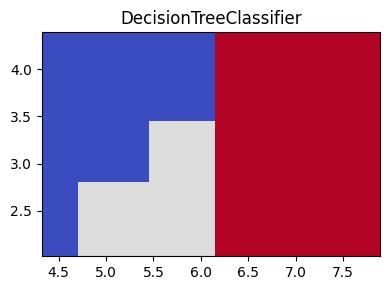

In [14]:
fix, ax = plt.subplots(1, 1, figsize=(4, 3))
for name, mod in tree_classifiers.items():
    plot_boundary(ax, iris.data, iris.target, mod, [0,1])
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [15]:
dtc = tree.DecisionTreeClassifier()
model_selection.cross_val_score(dtc, iris.data, iris.target, cv=3, scoring='accuracy')

array([0.98, 0.92, 0.98])

In [16]:
useclass=1
train_features, test_features, train_target, test_target = model_selection.train_test_split(iris.data, iris.target==useclass, test_size=0.33, random_state=21)
iris_tree = tree.DecisionTreeClassifier().fit(train_features, train_target)

In [17]:
dot_data=tree.export_graphviz(iris_tree, out_file=None)
graph=pydotplus.graph_from_dot_data(dot_data)
graph.write_png("iris1c.png")
Image("iris1c.png", width=500, height=500)

InvocationException: GraphViz's executables not found

In [9]:
iris_tree=(tree.DecisionTreeClassifier().fit(train_features, train_target))
with open("iris.dot", "w") as f:
    dot_data=tree.export_graphviz(iris_tree, out_file=f, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)